# MNIST Neural Network Experiments

### Exploring architecture, training settings, optimizers, hyperparameter tuning and weight initialization

**Goal:** Understand how different neural-network choices affect a handwritten-digit classifier.

## 1. Setup and MNIST data

First, load the libraries and prepare the MNIST images for a dense neural network.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

# Set seeds so repeated runs are more consistent
np.random.seed(42)
tf.random.set_seed(42)

# Load the handwritten-digit dataset
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

# Scale every pixel from 0-255 to 0-1
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# Convert each 28x28 image into a 784-value feature vector
train_images = train_images.reshape(train_images.shape[0], -1)
test_images = test_images.reshape(test_images.shape[0], -1)

# Reserve the final 10,000 training samples for validation
x_val, y_val = train_images[-10000:], train_labels[-10000:]
x_train, y_train = train_images[:-10000], train_labels[:-10000]

print("Training shape:", x_train.shape)
print("Validation shape:", x_val.shape)
print("Test shape:", test_images.shape)

Training shape: (50000, 784)
Validation shape: (10000, 784)
Test shape: (10000, 784)


## 2. Experiment: network architecture

I compare several combinations of hidden layers and neurons to see how model size affects validation accuracy and training time.

In [2]:
def make_classifier(hidden_layers=1, units=64):
    network = keras.Sequential(name="mnist_dense_network")
    network.add(layers.Input(shape=(784,)))

    # Add the requested number of fully-connected hidden layers
    for _ in range(hidden_layers):
        network.add(layers.Dense(units, activation="relu"))

    # Ten output classes: digits 0 through 9
    network.add(layers.Dense(10, activation="softmax"))

    network.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return network


architecture_tests = [
    {"hidden_layers": 1, "units": 32},
    {"hidden_layers": 1, "units": 96},
    {"hidden_layers": 1, "units": 160},
    {"hidden_layers": 2, "units": 48},
    {"hidden_layers": 2, "units": 96},
    {"hidden_layers": 2, "units": 160},
    {"hidden_layers": 3, "units": 64},
    {"hidden_layers": 3, "units": 128},
]

architecture_results = []

for config in architecture_tests:
    network = make_classifier(
        hidden_layers=config["hidden_layers"],
        units=config["units"]
    )

    start_time = time.perf_counter()

    history = network.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=5,
        batch_size=48,
        verbose=0
    )

    elapsed = time.perf_counter() - start_time

    architecture_results.append({
        "Hidden Layers": config["hidden_layers"],
        "Neurons / Layer": config["units"],
        "Training Time (s)": round(elapsed, 2),
        "Best Validation Accuracy": round(max(history.history["val_accuracy"]), 4)
    })

architecture_df = pd.DataFrame(architecture_results)
architecture_df

,Hidden Layers,Neurons / Layer,Training Time (s),Best Validation Accuracy
0,1,32,11.99,0.9566
1,1,96,14.44,0.9707
2,1,160,16.17,0.9726
3,2,48,13.16,0.9647
4,2,96,14.92,0.9722
5,2,160,17.34,0.9735
6,3,64,14.14,0.9705
7,3,128,16.85,0.9737


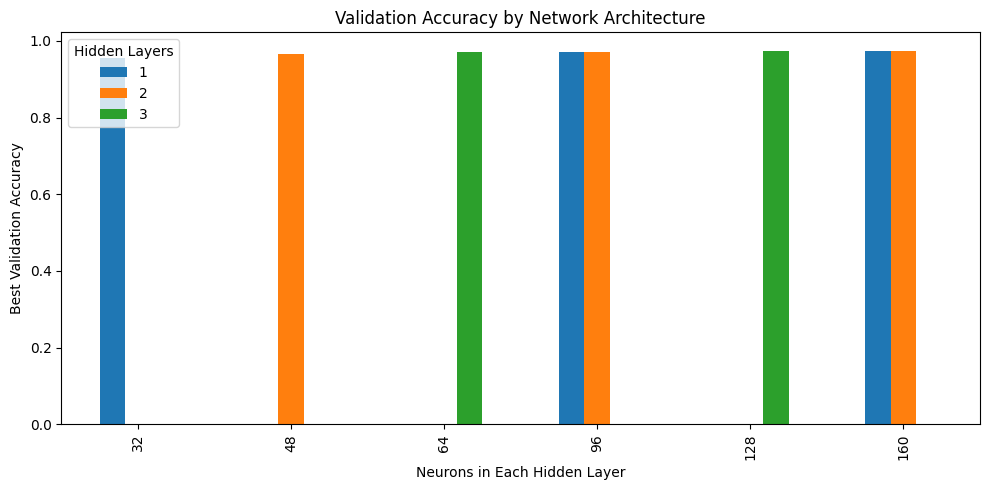

In [3]:
# Visual comparison of the architecture experiments
architecture_pivot = architecture_df.pivot(
    index="Neurons / Layer",
    columns="Hidden Layers",
    values="Best Validation Accuracy"
)

architecture_pivot.plot(kind="bar", figsize=(10, 5))

plt.title("Validation Accuracy by Network Architecture")
plt.xlabel("Neurons in Each Hidden Layer")
plt.ylabel("Best Validation Accuracy")
plt.legend(title="Hidden Layers")
plt.tight_layout()
plt.show()

## 3. Experiment: batch size and epochs

Next, I vary the batch size and number of epochs while keeping the network architecture fixed.

In [4]:
batch_options = [24, 48, 96]
epoch_options = [5, 10, 15]

training_results = []

for batch in batch_options:
    for epoch_count in epoch_options:
        network = make_classifier(hidden_layers=1, units=96)

        start_time = time.perf_counter()

        history = network.fit(
            x_train,
            y_train,
            validation_data=(x_val, y_val),
            epochs=epoch_count,
            batch_size=batch,
            verbose=0
        )

        elapsed = time.perf_counter() - start_time

        training_results.append({
            "Batch Size": batch,
            "Epochs": epoch_count,
            "Training Time (s)": round(elapsed, 2),
            "Final Validation Accuracy": round(history.history["val_accuracy"][-1], 4),
            "Best Validation Accuracy": round(max(history.history["val_accuracy"]), 4)
        })

training_df = pd.DataFrame(training_results)
training_df

,Batch Size,Epochs,Training Time (s),Final Validation Accuracy,Best Validation Accuracy
0,24,5,26.05,0.9710,0.9718
1,24,10,50.45,0.9757,0.9759
2,24,15,76.72,0.9736,0.9756
3,48,5,14.19,0.9699,0.9699
4,48,10,30.47,0.9731,0.9737
5,48,15,41.31,0.9713,0.9726
6,96,5,8.16,0.9706,0.9706
7,96,10,16.57,0.9722,0.9722
8,96,15,22.82,0.9741,0.9741


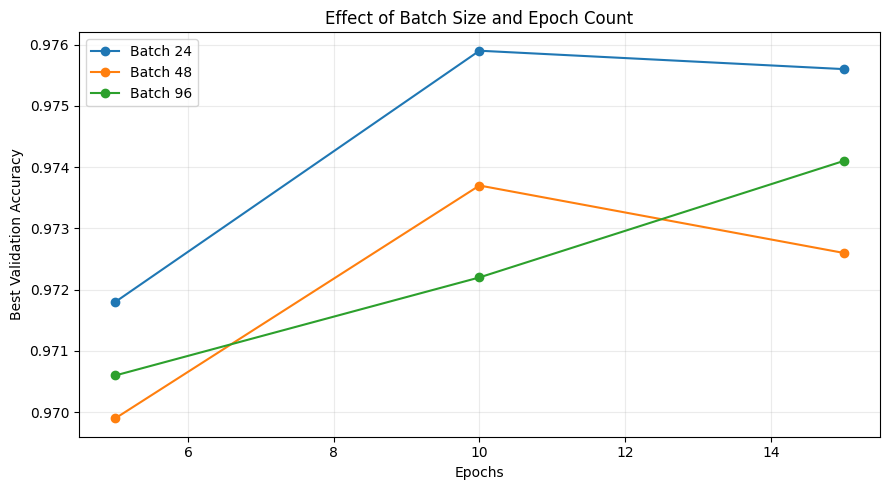

In [5]:
plt.figure(figsize=(9, 5))

for batch in batch_options:
    rows = training_df[training_df["Batch Size"] == batch]
    plt.plot(
        rows["Epochs"],
        rows["Best Validation Accuracy"],
        marker="o",
        label=f"Batch {batch}"
    )

plt.title("Effect of Batch Size and Epoch Count")
plt.xlabel("Epochs")
plt.ylabel("Best Validation Accuracy")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Experiment: comparing optimizers

The optimizer controls how model weights are updated during training. Here I compare **SGD, Adam and RMSprop**.

In [6]:
def build_optimizer_test(optimizer):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


optimizer_choices = {
    "SGD": keras.optimizers.SGD(learning_rate=0.01),
    "Adam": keras.optimizers.Adam(learning_rate=0.001),
    "RMSprop": keras.optimizers.RMSprop(learning_rate=0.001)
}

optimizer_history = {}

for label, optimizer in optimizer_choices.items():
    model = build_optimizer_test(optimizer)

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=10,
        batch_size=64,
        verbose=0
    )

    optimizer_history[label] = history

for label, history in optimizer_history.items():
    print(
        f"{label}: final validation accuracy = "
        f"{history.history['val_accuracy'][-1]:.4f}"
    )

SGD: final validation accuracy = 0.9504
Adam: final validation accuracy = 0.9739
RMSprop: final validation accuracy = 0.9729


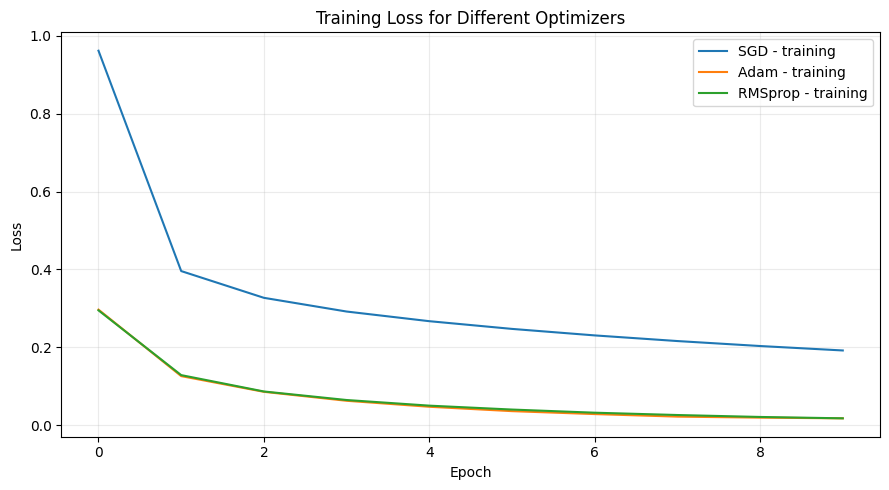

In [7]:
plt.figure(figsize=(9, 5))

for label, history in optimizer_history.items():
    plt.plot(history.history["loss"], label=f"{label} - training")

plt.title("Training Loss for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

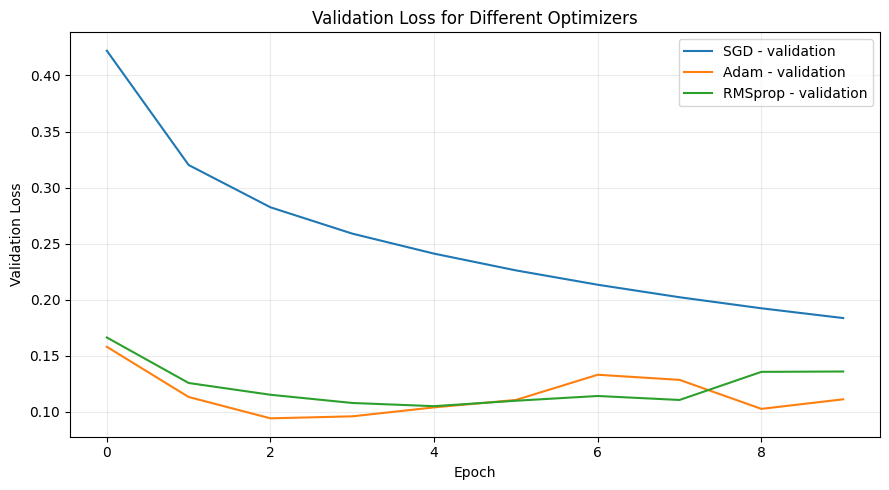

In [8]:
plt.figure(figsize=(9, 5))

for label, history in optimizer_history.items():
    plt.plot(history.history["val_loss"], label=f"{label} - validation")

plt.title("Validation Loss for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Hyperparameter tuning with KerasTuner

Instead of manually checking every neuron count, KerasTuner searches a defined range for a promising configuration.

> This section requires the `keras-tuner` package.

In [9]:
%pip install -q keras-tuner

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import keras_tuner as kt

def tuner_model(hp):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(
            units=hp.Int(
                "hidden_units",
                min_value=48,
                max_value=192,
                step=48
            ),
            activation="relu"
        ),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [11]:
searcher = kt.Hyperband(
    tuner_model,
    objective="val_accuracy",
    max_epochs=10,
    factor=3,
    directory="mnist_tuning",
    project_name="dense_network_search",
    overwrite=True
)

searcher.search(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

Trial 4 Complete [00h 00m 07s]
val_accuracy: 0.9652000069618225

Best val_accuracy So Far: 0.9652000069618225
Total elapsed time: 00h 00m 26s


In [12]:
best_parameters = searcher.get_best_hyperparameters(num_trials=1)[0]

print("Best hidden-unit setting:", best_parameters.get("hidden_units"))

best_network = searcher.get_best_models(num_models=1)[0]

test_loss, test_accuracy = best_network.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Best hidden-unit setting: 192


C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test loss: 0.1177
Test accuracy: 0.9646


## 6. Experiment: weight initialization

Finally, I compare different ways of initializing neural-network weights:

- `he_normal`
- `glorot_uniform`
- `random_normal`

This helps show how initialization can influence training.

In [13]:
initialization_methods = [
    "he_normal",
    "glorot_uniform",
    "random_normal"
]

initialization_histories = {}
initialization_summary = []

for method in initialization_methods:
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu", kernel_initializer=method),
        layers.Dense(64, activation="relu", kernel_initializer=method),
        layers.Dense(10, activation="softmax", kernel_initializer=method)
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.perf_counter()

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=10,
        batch_size=64,
        verbose=0
    )

    elapsed = time.perf_counter() - start_time

    initialization_histories[method] = history

    initialization_summary.append({
        "Initializer": method,
        "Training Time (s)": round(elapsed, 2),
        "Best Validation Accuracy": round(max(history.history["val_accuracy"]), 4),
        "Final Validation Accuracy": round(history.history["val_accuracy"][-1], 4)
    })

initialization_df = pd.DataFrame(initialization_summary)
initialization_df

,Initializer,Training Time (s),Best Validation Accuracy,Final Validation Accuracy
0,he_normal,24.04,0.9740,0.9740
1,glorot_uniform,24.30,0.9718,0.9683
2,random_normal,23.97,0.9730,0.9717


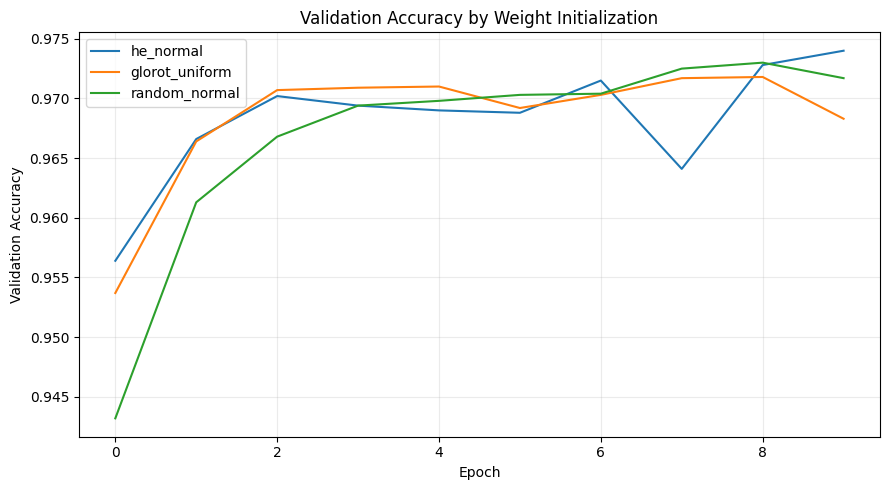

In [14]:
plt.figure(figsize=(9, 5))

for method, history in initialization_histories.items():
    plt.plot(history.history["val_accuracy"], label=method)

plt.title("Validation Accuracy by Weight Initialization")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

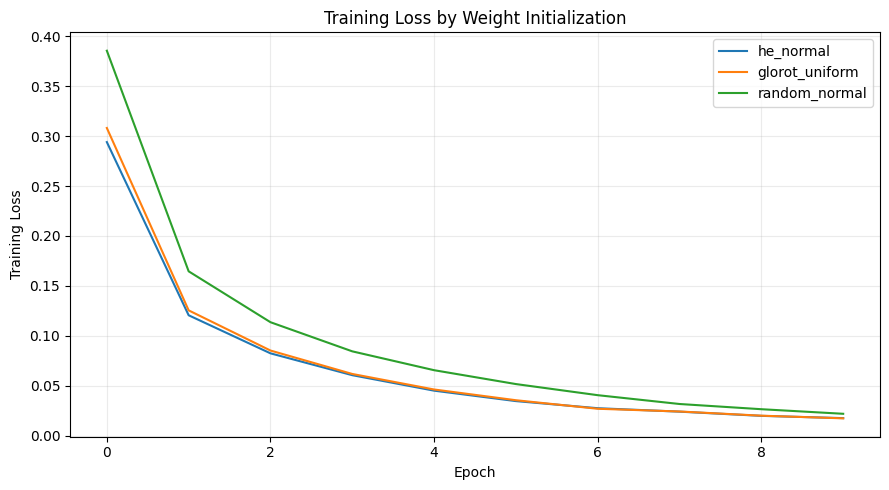

In [15]:
plt.figure(figsize=(9, 5))

for method, history in initialization_histories.items():
    plt.plot(history.history["loss"], label=method)

plt.title("Training Loss by Weight Initialization")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Summary

This notebook explores four practical areas:

1. **Network architecture** — hidden layers and neurons
2. **Training configuration** — batch size and epochs
3. **Optimization** — SGD, Adam and RMSprop
4. **Weight initialization** — different initialization strategies

I also used **KerasTuner** to automate part of the hyperparameter search.

The experiments are intended to compare model behaviour; the results can vary slightly between runs.